# Activity 2 — Predictive Analytics
**Course:** Data Analytics (10204210) | **Dataset:** Emergency Response

Steps:
1. Feature Selection (SelectKBest + RFE)
2. Linear Regression
3. K-Nearest Neighbors
4. Decision Tree
5. LSTM (Deep Learning)
6. Compare all models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE

In [2]:
# Load encoded dataset (all numeric) from Phase 0
df = pd.read_csv('df_encoded.csv')

# Take 2018-2019 subset using the Year column
df = df[df['Year'].isin([2018, 2019])].copy()
df.reset_index(drop=True, inplace=True)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (105120, 21)


,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Ambulance_Availability,Hospital_Capacity,Distance_to_Incident,Number_of_Injuries,Specialist_Availability,...,Emergency_Level,Ambulance_Speed,Fuel_Level,Weather_Impact,Dispatch_Coordinator,Response_Time,Year,Month,Hour,DayOfWeek
0,1,1,1,0,0,0,91,8.89,1,1,...,1,43.549849,90.030756,2,0,20.870220,2018,1,0,1
1,1,3,2,2,0,0,28,28.10,2,1,...,0,30.687975,88.255008,0,1,24.486195,2018,1,0,1
2,2,1,1,0,1,0,83,40.43,1,1,...,2,44.456331,97.719622,1,1,18.760740,2018,1,0,1
3,1,0,2,2,0,0,31,18.97,3,0,...,2,35.879968,60.234672,1,1,18.169534,2018,1,0,1
4,1,1,2,2,2,0,52,16.31,3,0,...,2,26.369383,71.083564,0,1,5.000000,2018,1,0,1


In [ ]:
# Define features (X) and target (y)
X = df.drop(['Response_Time'], axis=1) ## all columns EXCEPT the target = inputs (20 features
y = df['Response_Time'] ## the target we predict

print('Features:', X.shape)
print('Target:', y.shape)

Features: (105120, 20)
Target: (105120,)


## Feature Selection

In [ ]:
# Split and scale before feature selection
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) # Split the data

scaler = StandardScaler()
#rescales each feature to mean 0, std 1 using z = (x − mean) / std. Essential because KNN (distances) and 
# LSTM (gradient descent) are sensitive to feature scale — without it, Hospital_Capacity (0–99) would dominate 
# Number_of_Injuries (1–4).
X_train_scaled = scaler.fit_transform(X_train) ## Learn + Apply
#fit_transform on train (learns mean/std from train only), then transform on test (reuses the train statistics). 
# This prevents data leakage — the test set must not influence preprocessing.
X_test_scaled  = scaler.transform(X_test) ## Apply only

In [ ]:
# Method 1: SelectKBest with f_regression
#F = (Explained Variance) / (Unexplained Variance)
selector = SelectKBest(f_regression, k=10) # Select the top 10 features based on univariate linear regression tests.
selector.fit(X_train_scaled, y_train) # Fit the selector on the training data

selected_features_kbest = X.columns[selector.get_support()]# get_support() returns a boolean mask of the selected features, 
# which we use to index the original column names.
print('SelectKBest — Selected features:')
print(list(selected_features_kbest))

X_train_kbest = selector.transform(X_train_scaled) ## Transform the training data to include only the selected features
X_test_kbest  = selector.transform(X_test_scaled) # Transform the test data using the same selector 

SelectKBest — Selected features:
['Incident_Type', 'Region_Type', 'Traffic_Congestion', 'Hospital_Capacity', 'Distance_to_Incident', 'Emergency_Level', 'Fuel_Level', 'Dispatch_Coordinator', 'Year', 'Month']


In [6]:
# Method 2: RFE (Recursive Feature Elimination)
rfe = RFE(estimator=LinearRegression(), n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)

selected_features_rfe = X.columns[rfe.get_support()]
print('RFE — Selected features:')
print(list(selected_features_rfe))

X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe  = rfe.transform(X_test_scaled)

RFE — Selected features:
['Incident_Type', 'Region_Type', 'Traffic_Congestion', 'Hospital_Capacity', 'Distance_to_Incident', 'Emergency_Level', 'Fuel_Level', 'Dispatch_Coordinator', 'Year', 'Month']


In [7]:
# Features agreed by both methods
common = set(selected_features_kbest) & set(selected_features_rfe)
print('Features selected by BOTH methods:')
print(common)

Features selected by BOTH methods:
{'Emergency_Level', 'Year', 'Month', 'Region_Type', 'Dispatch_Coordinator', 'Traffic_Congestion', 'Hospital_Capacity', 'Incident_Type', 'Distance_to_Incident', 'Fuel_Level'}


## Prepare Final Feature Set and Store Results

In [8]:
# Use all features for modelling
# Results dictionary to store metrics for all models
Results = {}

## Model 1 — Linear Regression

In [9]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred_lr)
mse  = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_lr)

Results['Linear Regression'] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
print('Linear Regression:')
print(f'  MAE={mae:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

Linear Regression:
  MAE=3.9383  MSE=23.8688  RMSE=4.8856  R2=-0.0005


## Model 2 — K-Nearest Neighbors

In [10]:
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred_knn)
mse  = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_knn)

Results['KNN'] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
print('KNN Regressor:')
print(f'  MAE={mae:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

KNN Regressor:
  MAE=4.2959  MSE=28.6308  RMSE=5.3508  R2=-0.2001


## Model 3 — Decision Tree

In [ ]:
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train_scaled, y_train)
y_pred_dt = model_dt.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred_dt)
mse  = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_dt)

Results['Decision Tree'] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
print('Decision Tree:')
print(f'  MAE={mae:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

# adding a max depth would help with the overfitting of the decision tree model, 
# as it would limit the complexity of the tree and prevent it from learning noise in the training data.

Decision Tree:
  MAE=5.7135  MSE=50.5720  RMSE=7.1114  R2=-1.1198


## Model 4 — LSTM (Deep Learning)

In [ ]:
import tensorflow as tf
#Long Short-Term Memory, a type of Recurrent Neural Network (RNN) designed for sequences/time series;
#  its internal "gates" let it remember/forget information over time.
# Reshape input data for LSTM: (samples, timesteps, features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))

# by making the timesteps = 1, we are treating each sample as a single time step with multiple features.
# this si due to our data doesnt have continuous time series , so like that the LTSM wroks is regulare RNN 

X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print('LSTM input shape:', X_train_lstm.shape)

LSTM input shape: (84096, 1, 20)


In [ ]:
# Build the LSTM model
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, activation='relu', #LSTM layer with 64 units and ReLU activation function
    input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])), # input shape = (timesteps, features) = (1, 20)
    tf.keras.layers.Dense(32, activation='relu'), # Dense layer with 32 units and ReLU activation function
    tf.keras.layers.Dense(1)   # Output layer with 1 unit (for regression) and no activation function (linear)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae']) #Adam = Adaptive Moment Estimation
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,873 (93.25 KB)

 Trainable params: 23,873 (93.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the LSTM model
history = model_lstm.fit(
    X_train_lstm, y_train,
    validation_data=(X_test_lstm, y_test),
    epochs=50,
    batch_size=64,
    verbose=1
)

Epoch 1/50
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 40.6949 - mae: 4.8720 - val_loss: 25.0466 - val_mae: 4.0322
Epoch 2/50
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 24.5424 - mae: 3.9915 - val_loss: 24.4643 - val_mae: 3.9876
Epoch 3/50
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 24.2125 - mae: 3.9649 - val_loss: 24.1660 - val_mae: 3.9614
Epoch 4/50
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 24.0879 - mae: 3.9565 - val_loss: 24.3398 - val_mae: 3.9763
Epoch 5/50
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 24.0018 - mae: 3.9498 - val_loss: 24.3078 - val_mae: 3.9711
Epoch 6/50
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 23.9438 - mae: 3.9435 - val_loss: 24.1637 - val_mae: 3.9626
Epoch 7/50
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 23.8963 - mae: 3.9413 - val_loss: 24.1903 - val_mae: 3.9603
Epoch 8/50
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 23.8703 - mae: 3.9392 - val_loss: 24.0341 - val_mae: 3.9513
Epoch 9/50
1314/1314 ━━

In [15]:
# Evaluate LSTM
y_pred_lstm = model_lstm.predict(X_test_lstm).flatten()

mae  = mean_absolute_error(y_test, y_pred_lstm)
mse  = mean_squared_error(y_test, y_pred_lstm)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_lstm)

Results['LSTM'] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
print('LSTM:')
print(f'  MAE={mae:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
LSTM:
  MAE=4.0502  MSE=25.3002  RMSE=5.0299  R2=-0.0605


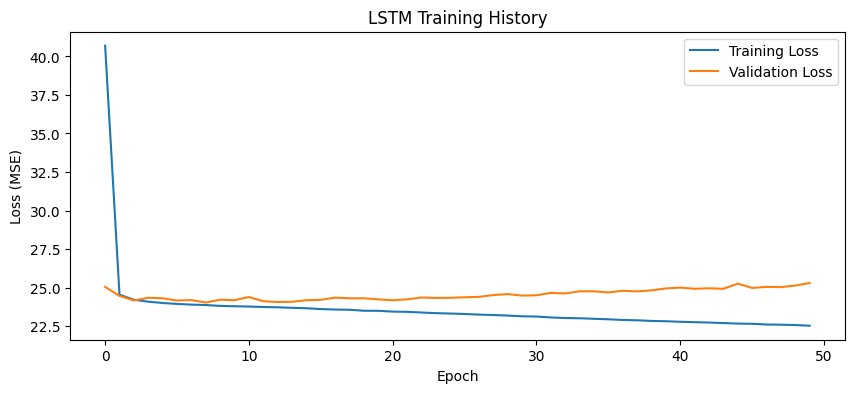

In [16]:
# Plot LSTM training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

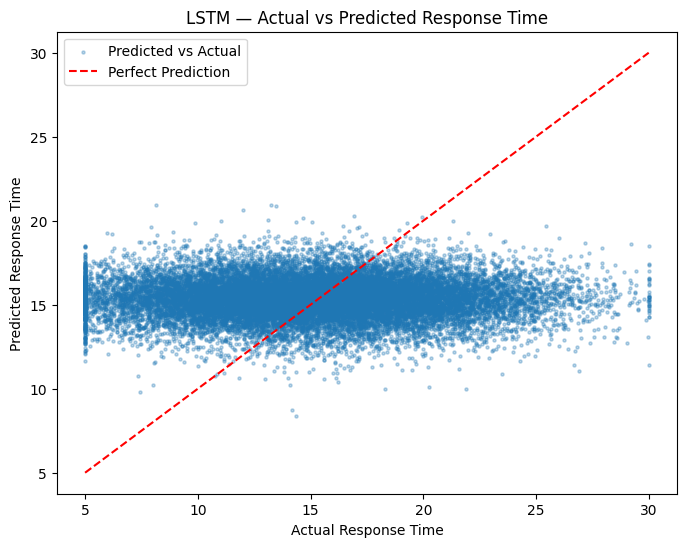

In [17]:
# Actual vs Predicted — LSTM
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lstm, alpha=0.3, s=5, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.title('LSTM — Actual vs Predicted Response Time')
plt.xlabel('Actual Response Time')
plt.ylabel('Predicted Response Time')
plt.legend()
plt.show()

## Model Comparison

In [18]:
# Summary table
pd.DataFrame(Results).round(4)

,Linear Regression,KNN,Decision Tree,LSTM
MAE,3.9383,4.2959,5.7135,4.0502
MSE,23.8688,28.6308,50.5720,25.3002
RMSE,4.8856,5.3508,7.1114,5.0299
R2,-0.0005,-0.2001,-1.1198,-0.0605


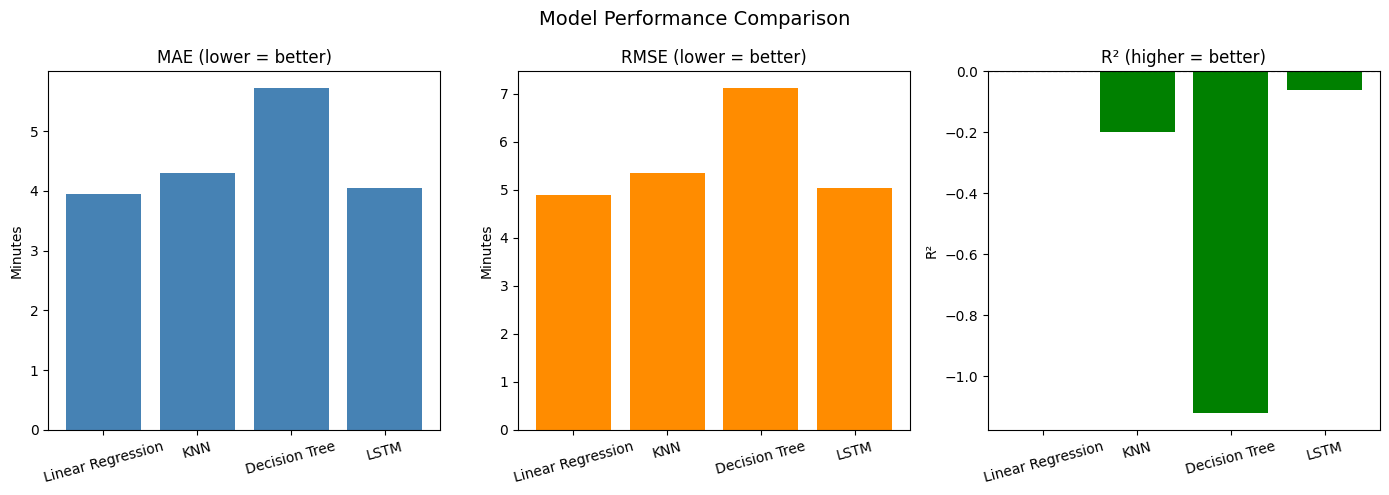

In [19]:
# Bar chart comparison
model_names = list(Results.keys())
mae_values  = [Results[m]['MAE']  for m in model_names]
rmse_values = [Results[m]['RMSE'] for m in model_names]
r2_values   = [Results[m]['R2']   for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(model_names, mae_values, color='steelblue')
axes[0].set_title('MAE (lower = better)')
axes[0].set_ylabel('Minutes')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(model_names, rmse_values, color='darkorange')
axes[1].set_title('RMSE (lower = better)')
axes[1].set_ylabel('Minutes')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(model_names, r2_values, color='green')
axes[2].set_title('R² (higher = better)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=15)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## Multiple Runs — Boxplot Comparison (Linear Regression, KNN, Decision Tree)

In [21]:
# Multiple Runs — Boxplot Comparison (30 runs on a 10k sample for speed)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Use a 10,000-row sample to keep runtime reasonable
df_sample = df.sample(n=10000, random_state=42).reset_index(drop=True)
X_s = df_sample.drop(['Response_Time'], axis=1)
y_s = df_sample['Response_Time']

results_multi = {
    'Linear Regression': {'MAE': [], 'RMSE': [], 'R2': []},
    'KNN':               {'MAE': [], 'RMSE': [], 'R2': []},
    'Decision Tree':     {'MAE': [], 'RMSE': [], 'R2': []},
}

for i in range(30):
    X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.2, random_state=i)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s  = sc.transform(X_te)

    for name, model in [
        ('Linear Regression', LinearRegression()),
        ('KNN',               KNeighborsRegressor(n_neighbors=5)),
        ('Decision Tree',     DecisionTreeRegressor(random_state=i)),
    ]:
        model.fit(X_tr_s, y_tr)
        p = model.predict(X_te_s)
        results_multi[name]['MAE'].append(mean_absolute_error(y_te, p))
        results_multi[name]['RMSE'].append(np.sqrt(mean_squared_error(y_te, p)))
        results_multi[name]['R2'].append(r2_score(y_te, p))

print('30 runs complete.')

30 runs complete.


In [22]:
# Average results across 100 runs
avg_results = {}
for model in results_multi:
    avg_results[model] = {metric: np.mean(values)
                          for metric, values in results_multi[model].items()}
print('Average results across 100 runs:')
pd.DataFrame(avg_results).round(4)

Average results across 100 runs:


,Linear Regression,KNN,Decision Tree
MAE,3.9022,4.2692,5.6639
RMSE,4.8540,5.3299,7.0545
R2,-0.0035,-0.2101,-1.1211


/tmp/ipykernel_2727/417367502.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([results_multi[m]['MAE'] for m in results_multi],


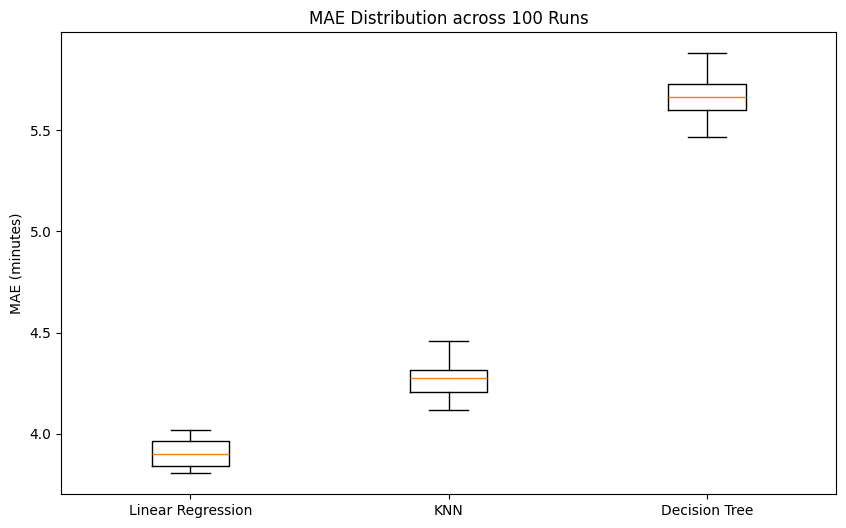

In [23]:
# Boxplot — MAE across 100 runs
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([results_multi[m]['MAE'] for m in results_multi],
           labels=list(results_multi.keys()))
ax.set_title('MAE Distribution across 100 Runs')
ax.set_ylabel('MAE (minutes)')
plt.show()

/tmp/ipykernel_2727/3767234426.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([results_multi[m]['RMSE'] for m in results_multi],


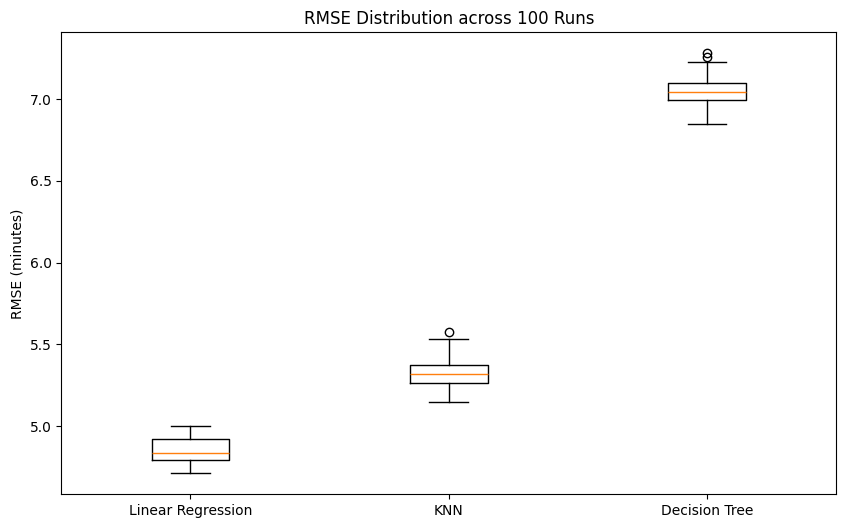

In [24]:
# Boxplot — RMSE across 100 runs
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([results_multi[m]['RMSE'] for m in results_multi],
           labels=list(results_multi.keys()))
ax.set_title('RMSE Distribution across 100 Runs')
ax.set_ylabel('RMSE (minutes)')
plt.show()

/tmp/ipykernel_2727/4124018900.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([results_multi[m]['R2'] for m in results_multi],


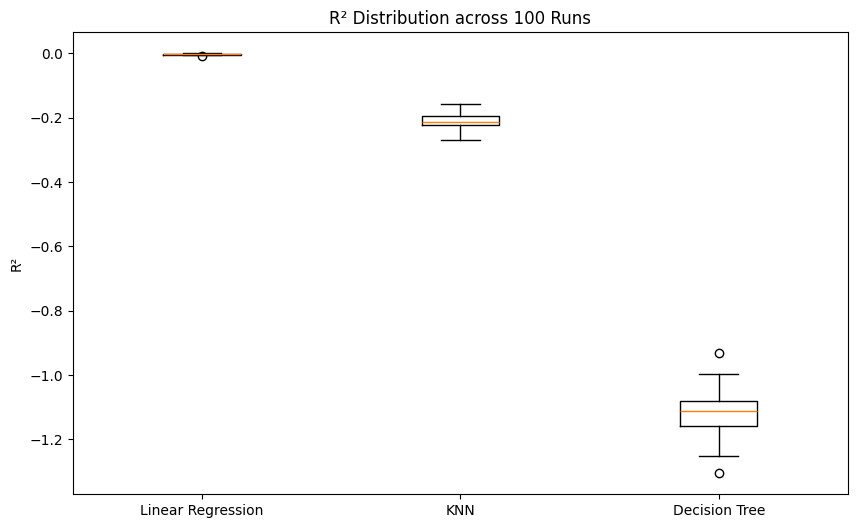

In [25]:
# Boxplot — R² across 100 runs
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([results_multi[m]['R2'] for m in results_multi],
           labels=list(results_multi.keys()))
ax.set_title('R² Distribution across 100 Runs')
ax.set_ylabel('R²')
plt.show()